# Multi-Factor Strategy

This notebook combines multiple factors into a single investment score:

- Momentum Factor
- Volatility Factor
- Size Factor

The objective is to rank stocks using a composite factor score and identify attractive investment opportunities.

In [1]:
import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt

Create Factor Data

In [2]:
# Download AAPL data

data = yf.download("AAPL", start="2023-01-01", end="2024-01-01")

# Flatten columns if needed
if isinstance(data.columns, pd.MultiIndex):
    data.columns = data.columns.get_level_values(0)

# Create factors
data["Momentum_20"] = data["Close"].pct_change(20)

data["Volatility_20"] = (
    data["Close"].pct_change().rolling(20).std()
)

data["Size_Factor"] = np.log(data["Volume"])

data[["Momentum_20", "Volatility_20", "Size_Factor"]].tail()

[*********************100%***********************]  1 of 1 completed


Price,Momentum_20,Volatility_20,Size_Factor
Date,,,
2023-12-22,0.019108,0.009071,17.430464
2023-12-26,0.017177,0.009103,17.180020
2023-12-27,0.014443,0.009086,17.688537
2023-12-28,0.022232,0.008973,17.343338
2023-12-29,0.013583,0.009078,17.569056


Standardize Factors

In [3]:
# Z-score normalization

data["Momentum_Z"] = (
    data["Momentum_20"] - data["Momentum_20"].mean()
) / data["Momentum_20"].std()

data["Volatility_Z"] = (
    data["Volatility_20"] - data["Volatility_20"].mean()
) / data["Volatility_20"].std()

data["Size_Z"] = (
    data["Size_Factor"] - data["Size_Factor"].mean()
) / data["Size_Factor"].std()

data[["Momentum_Z", "Volatility_Z", "Size_Z"]].tail()

Price,Momentum_Z,Volatility_Z,Size_Z
Date,,,
2023-12-22,-0.256934,-1.191685,-1.616583
2023-12-26,-0.290612,-1.180323,-2.560388
2023-12-27,-0.338286,-1.186272,-0.644025
2023-12-28,-0.202467,-1.227604,-1.944919
2023-12-29,-0.353292,-1.189469,-1.094293


Create Composite Factor Score

In [4]:
# Equal-weight multi-factor score

data["Factor_Score"] = (
    data["Momentum_Z"]
    - data["Volatility_Z"]
    + data["Size_Z"]
)

data[["Momentum_Z",
      "Volatility_Z",
      "Size_Z",
      "Factor_Score"]].tail()

Price,Momentum_Z,Volatility_Z,Size_Z,Factor_Score
Date,,,,
2023-12-22,-0.256934,-1.191685,-1.616583,-0.681831
2023-12-26,-0.290612,-1.180323,-2.560388,-1.670676
2023-12-27,-0.338286,-1.186272,-0.644025,0.203961
2023-12-28,-0.202467,-1.227604,-1.944919,-0.919782
2023-12-29,-0.353292,-1.189469,-1.094293,-0.258117


Plot Factor Score

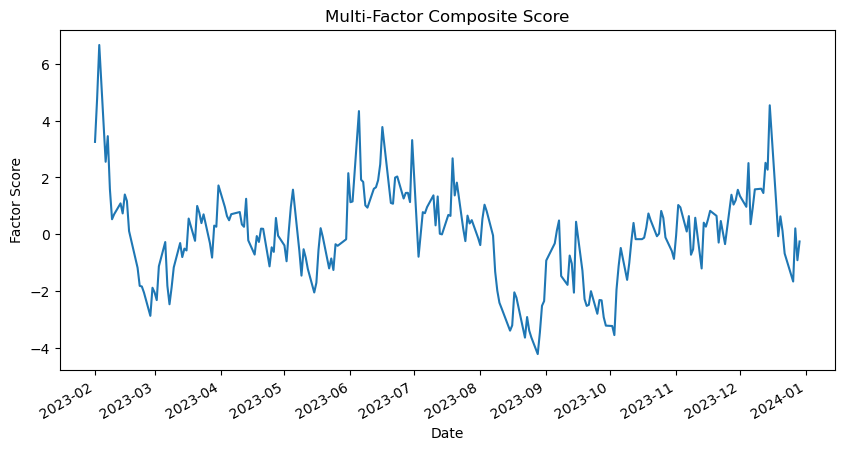

In [5]:
plt.figure(figsize=(10,5))

data["Factor_Score"].plot()

plt.title("Multi-Factor Composite Score")
plt.xlabel("Date")
plt.ylabel("Factor Score")

plt.show()

## Multi-Factor Results

The composite factor score combines Momentum, Volatility, and Size factors.

Positive scores indicate stronger overall factor characteristics, while negative scores indicate weaker characteristics.

The factor score fluctuates throughout the year, suggesting changing market conditions and factor performance.

This combined factor may provide more robust investment signals than relying on a single factor.